# 2107541 Machine Learning for Environmental Applications
## Homework 1 : Classification Models for Water Quality and Potability
### Done By : 6730084521 Chatrphol Ovanonchai
#### Disclaimer : All of these code were written by myself , No AI-Assisted (But used for Guided Learning)

## Part 0 : Data Preprocessing

### Step 1 :  Import the dataset

In [2]:
# Import Data
import pandas as pd # DataFrame
import seaborn as sns # Data Visualization 
import numpy as np # NumPy for Calculation
import matplotlib.pyplot as plt # Data Visualization
## scikit-learn will be imported in cell

data = pd.read_csv("./water_potability.csv")
data.head(5) # show only first 5 rows

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


### Step 2 : Check for `NULL` values and remove records containing `NULL` values using `dropna()`

In [3]:
## Check Count of Data dropna() 
print("Original Data Counts (with NULL/NaN) : " , len(data))
print("Cleaned Data Counts (without NULL/NaN) : " , len(data.dropna()) ) 

## From this info , we can summarize that data was drop around 38.6% (which is not good) 
## maybe we should do some "techniques" that can manage NULL data i.e. Data Imputation (Details in Part II)

Original Data Counts (with NULL/NaN) :  3276
Cleaned Data Counts (without NULL/NaN) :  2011


In [4]:
## Drop NULL Values
data = data.dropna().reset_index(drop = True) # reset index
data

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
1,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
2,5.584087,188.313324,28748.687739,7.544869,326.678363,280.467916,8.399735,54.917862,2.559708,0
3,10.223862,248.071735,28749.716544,7.513408,393.663396,283.651634,13.789695,84.603556,2.672989,0
4,8.635849,203.361523,13672.091764,4.563009,303.309771,474.607645,12.363817,62.798309,4.401425,0
...,...,...,...,...,...,...,...,...,...,...
2006,8.989900,215.047358,15921.412018,6.297312,312.931022,390.410231,9.899115,55.069304,4.613843,1
2007,6.702547,207.321086,17246.920347,7.708117,304.510230,329.266002,16.217303,28.878601,3.442983,1
2008,11.491011,94.812545,37188.826022,9.263166,258.930600,439.893618,16.172755,41.558501,4.369264,1
2009,6.069616,186.659040,26138.780191,7.747547,345.700257,415.886955,12.067620,60.419921,3.669712,1


### Step 3 : Check basic descriptive statistics using `.describe()`

In [5]:
data.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000
mean,7.085990,195.968072,21917.441374,7.134338,333.224672,426.526409,14.357709,66.400859,3.969729,0.403282
std,1.573337,32.635085,8642.239815,1.584820,41.205172,80.712572,3.324959,16.077109,0.780346,0.490678
min,0.227499,73.492234,320.942611,1.390871,129.000000,201.619737,2.200000,8.577013,1.450000,0.000000
25%,6.089723,176.744938,15615.665390,6.138895,307.632511,366.680307,12.124105,55.952664,3.442915,0.000000
50%,7.027297,197.191839,20933.512750,7.143907,332.232177,423.455906,14.322019,66.542198,3.968177,0.000000
75%,8.052969,216.441070,27182.587067,8.109726,359.330555,482.373169,16.683049,77.291925,4.514175,1.000000
max,14.000000,317.338124,56488.672413,13.127000,481.030642,753.342620,27.006707,124.000000,6.494749,1.000000


### Step 4 : Define the input features (X) and target (y)

In [6]:
feature_x = data[ ['ph','Hardness','Solids','Chloramines','Sulfate','Conductivity','Organic_carbon','Trihalomethanes','Turbidity'] ] # DataFrame
target_y = data['Potability'] # Series

## btw , we can use RandomForestClassifier to see which feature is important enough to use (Details in Part II)
## I've tried using correlation of each column , but each feature didnt seem to be important enough to be chosen (around 2-5%) , so nvm.

### Step 5 : Split the dataset into training and testing sets (80:20)

In [7]:
## from docs , we need to use train_test_split from sklearn.model_selection
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(feature_x , target_y , test_size = 0.2 , random_state = 42) # 80% Train , 20% Test

### Step 6 : Perform other appropriate data preprocessing, if needed
Using `RobustScaler` already in Step 7 , and I think cutting some data may affect the result. So just pass this one

### Step 7 : Apply feature scaling when appropriate
Note that we should do these steps after `train_test_split` already

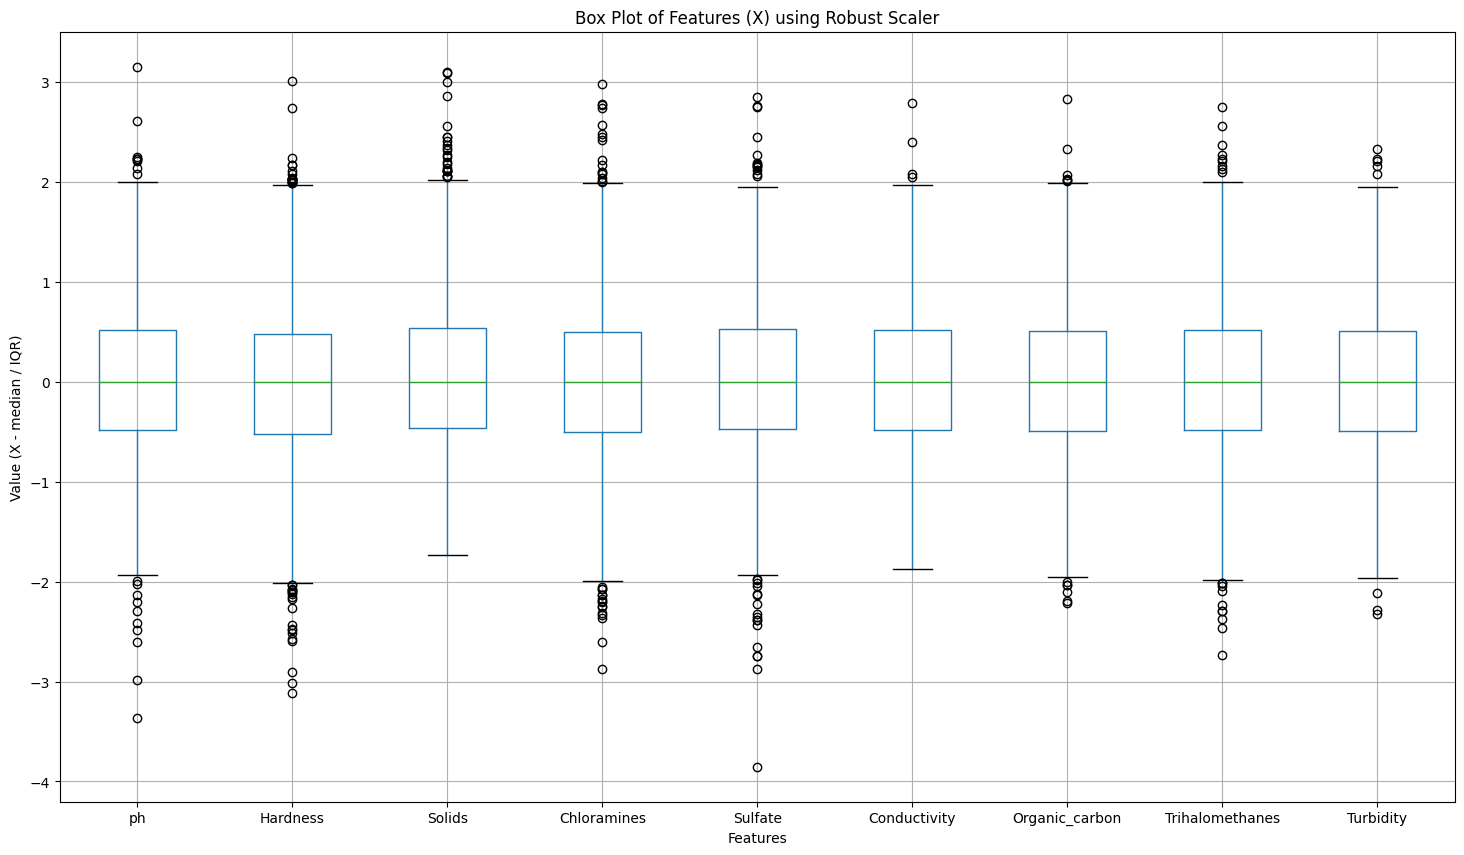

In [8]:
from sklearn.preprocessing import MinMaxScaler , RobustScaler , StandardScaler ## read from docs 

## Imma try using 1 of these scaler for easier ways (using StandardScaler)
scaler = RobustScaler() ## choosing robust scaler because it uses "median" to calculate , which is better look in boxplot

## fit & transform data
x_train_scaled = scaler.fit_transform(x_train) # return np array 
x_test_scaled = scaler.transform(x_test) ## Don't fit because fit will learn from this data

## Y (target) shouldn't be scaled bcz Y is between (0,1) which should be use in this form

## convert scaled data to DataFrame first 
x_train_scaled_df = pd.DataFrame(data = x_train_scaled , columns = feature_x.columns)

## plotting box plot for trend
x_train_scaled_df.boxplot(figsize = (18,10))

## Decorate Box Plot
plt.title("Box Plot of Features (X) using Robust Scaler")
plt.xlabel("Features") ; plt.ylabel("Value (X - median / IQR)") ;
plt.show() 

## Part I : Data Processing

Key : 
- `X_train & Y_train` -- Train --> Model

- Model --> predict with `X_test` --> `Y_predict` <-- Compare --> `Y_test`

 ### Model I : Decision Tree

#### Step 1 : Train Decision Tree Model (No need to scale data)

In [9]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(max_depth = 3 , random_state = 42 , ccp_alpha = 0) # I'll use depth as 3 first , optimize later in Part IV
decision_tree_model.fit(x_train , y_train)

DecisionTreeClassifier(ccp_alpha=0, max_depth=3, random_state=42)

#### Step 2 : Predict Data

In [10]:
### Step 2 : Predict Data with x_test
y_predicted_from_dt = decision_tree_model.predict(x_test) # predict input samples (which is x_train)
y_predicted_from_dt

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [11]:
## See Value Counts of Prediction
# Transform to DataFrame then check with .value_counts() 
pd.Series(y_predicted_from_dt).value_counts()

0    390
1     13
Name: count, dtype: int64

#### Step 3 : Plot a Decision Tree

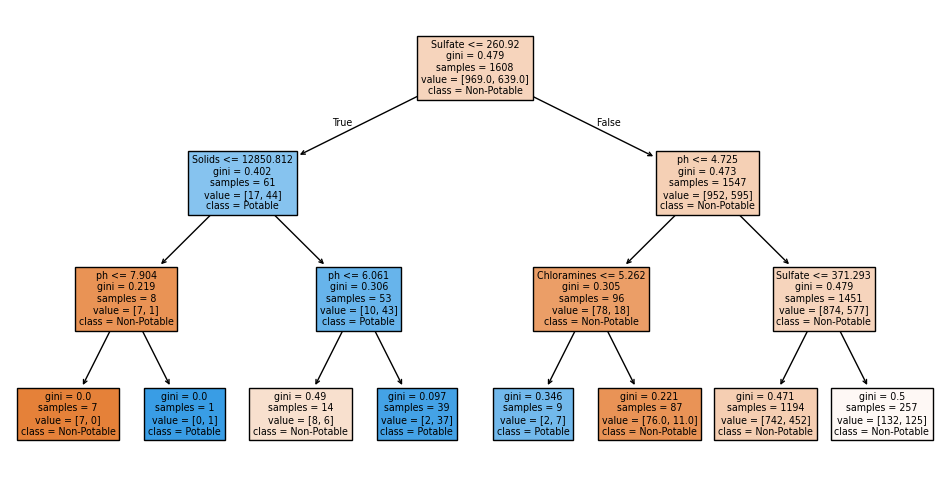

In [12]:
from sklearn.tree import plot_tree

plt.figure(figsize = (12,6))
plot_tree(decision_tree = decision_tree_model , feature_names = x_train.columns , class_names = ['Non-Potable','Potable'] , 
          filled = True) ## use column name from x_train
plt.show()

In [13]:
## Export to text
from sklearn.tree import export_text
print(export_text(decision_tree = decision_tree_model , feature_names = x_train.columns , class_names = ['Non-Potable','Potable']))

|--- Sulfate <= 260.92
|   |--- Solids <= 12850.81
|   |   |--- ph <= 7.90
|   |   |   |--- class: Non-Potable
|   |   |--- ph >  7.90
|   |   |   |--- class: Potable
|   |--- Solids >  12850.81
|   |   |--- ph <= 6.06
|   |   |   |--- class: Non-Potable
|   |   |--- ph >  6.06
|   |   |   |--- class: Potable
|--- Sulfate >  260.92
|   |--- ph <= 4.72
|   |   |--- Chloramines <= 5.26
|   |   |   |--- class: Potable
|   |   |--- Chloramines >  5.26
|   |   |   |--- class: Non-Potable
|   |--- ph >  4.72
|   |   |--- Sulfate <= 371.29
|   |   |   |--- class: Non-Potable
|   |   |--- Sulfate >  371.29
|   |   |   |--- class: Non-Potable



#### Note that we'll optimize `max_depth` for Decision Tree Model in Part IV

### Model II : Naive Bayes

#### Step 1 : Train Naive Bayes with `GuassianNB`

In [14]:
from sklearn.naive_bayes import GaussianNB

## define model
guassian_naive_bayes_model = GaussianNB()

## fit data with x_trained & y_trained
guassian_naive_bayes_model.fit(x_train , y_train)

GaussianNB()

#### Step 2 : Predict Data

In [15]:
y_predicted_from_gnb = guassian_naive_bayes_model.predict(x_test) # predict with x_test
y_predicted_from_gnb

array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,

### Model III : Logistic Regression

#### Note that Output will return `RuntimeWarning` from Apple BLAS (which is not my problem) , so I'll ignore these output with the code below (AI-Generated)

In [16]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

#### Step 1 : Train Model
Note that I choose `C = 1` as default value of regularization. btw we can optimize by using `GridSearchCV` in Part IV

In [17]:
from sklearn.linear_model import LogisticRegression

## define model
logistic_regression_model = LogisticRegression(C = 1 , penalty = None) # given regularization as 1 

## train data with .fit()
logistic_regression_model.fit(x_train_scaled , y_train)

LogisticRegression(C=1, penalty=None)

#### Step 2 : Predict Data

In [18]:
y_predicted_from_log_reg = logistic_regression_model.predict(x_test_scaled)
y_predicted_from_log_reg

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

#### Step 3 : Plot Logistic Regression

In [19]:
## define x-axis range (which is Z-score , not from x_test_scaled bcz we use Z for probability)
x_axis_zscore = logistic_regression_model.decision_function(x_test_scaled)

## define y-axis : probability predicted from each class
y_predicted_prob_from_log_reg = logistic_regression_model.predict_proba(x_test_scaled)

y_predicted_prob_from_log_reg # [class 0 (Non-Potable) , class 1 (Potable)] --> choose by [: , 0/1]

array([[0.57058408, 0.42941592],
       [0.55080782, 0.44919218],
       [0.60119663, 0.39880337],
       [0.53495022, 0.46504978],
       [0.63014084, 0.36985916],
       [0.58156623, 0.41843377],
       [0.59416011, 0.40583989],
       [0.58577579, 0.41422421],
       [0.63454396, 0.36545604],
       [0.61773668, 0.38226332],
       [0.54876606, 0.45123394],
       [0.70860325, 0.29139675],
       [0.55051325, 0.44948675],
       [0.59563636, 0.40436364],
       [0.49758313, 0.50241687],
       [0.61705641, 0.38294359],
       [0.58721925, 0.41278075],
       [0.62311899, 0.37688101],
       [0.54489118, 0.45510882],
       [0.58806569, 0.41193431],
       [0.63302345, 0.36697655],
       [0.57401924, 0.42598076],
       [0.54314867, 0.45685133],
       [0.63141218, 0.36858782],
       [0.62068987, 0.37931013],
       [0.62010668, 0.37989332],
       [0.65133289, 0.34866711],
       [0.58213276, 0.41786724],
       [0.58091847, 0.41908153],
       [0.60813945, 0.39186055],
       [0.

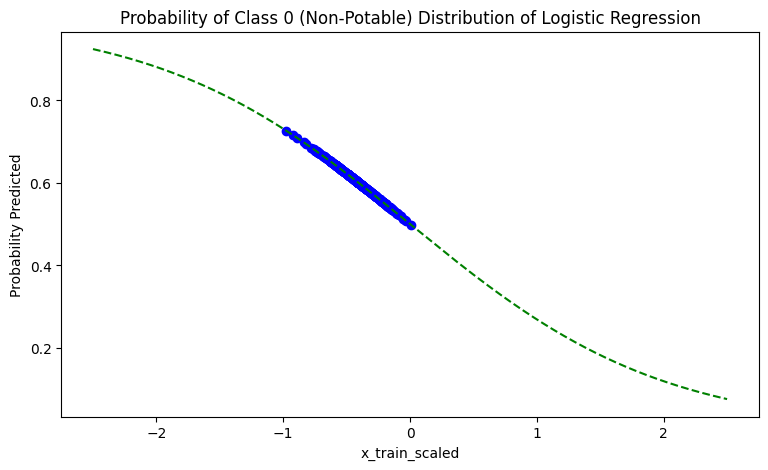

In [20]:
## visualize some probability distribution for logistic regression

## define sigmoid function 
def sigmoid_line(z) : 
    return 1 / (1 + np.exp(-z))

## Overview (Predicted as 0/1)
plt.figure(figsize = (9,5))
z_range = np.linspace(-2.5, 2.5, 500)

order_x = np.argsort(x_axis_zscore) ## return index of sorted elements as array form i.e. [2,1,0]

## Plot probability for class 0 (Non-Potable = Undrinkable)
plt.scatter(x_axis_zscore , y_predicted_prob_from_log_reg[: , 0] , color = "blue") ## scatter data 
plt.plot(z_range , 1 - sigmoid_line(z_range) , color = "green" , linestyle = "--") ## plot sigmoid line
## reverse sigmoid bcz we're predicting class 0 (not class 1 as usual)

plt.title("Probability of Class 0 (Non-Potable) Distribution of Logistic Regression")
plt.xlabel("x_train_scaled") ; plt.ylabel("Probability Predicted") 
plt.show()

### Model IV : Support Vector Machine

#### Step 1 : Train Model

In [21]:
from sklearn.svm import SVC # Support Vector Classifier

## define model 
support_vector_machine_model = SVC(kernel = "rbf" , C = 1) # kernel trick = rbf (from non-linear relationship)

## Train Model
support_vector_machine_model.fit(x_train_scaled , y_train)

SVC(C=1)

#### Step 2 : Predict Model

In [22]:
y_predicted_from_svm = support_vector_machine_model.predict(x_test_scaled)
y_predicted_from_svm

array([0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,

#### Step 4 : Plotting Decision Boundary
Note that we've to use 2 columns to do SVM. So we have to use PCA to decrease dimensions. Which is too hard to do it now. So I'll skip.

### Model V : K-Nearest Neighbors

#### Step 1 : Train Model 
Note that I use `K = 3` , which maybe better oslution if using another K , So I'll optimize it in Part IV

In [23]:
from sklearn.neighbors import KNeighborsClassifier

## define model
k_nearest_neighbors_model = KNeighborsClassifier(n_neighbors = 3)

## train data using .fit()
k_nearest_neighbors_model.fit(x_train_scaled , y_train)

KNeighborsClassifier(n_neighbors=3)

#### Step 2 : Predict Data 

In [24]:
## predict data with .predict --> predict with x_test_scaled
y_predicted_from_knn = k_nearest_neighbors_model.predict(x_test_scaled)
y_predicted_from_knn

array([0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0,

#### Step 3 : Plotting Decision Boundary
Note that we've to use 2 columns to do KNN. So we have to use PCA to decrease dimensions. Which is too hard to do it now. So I'll skip.

## Part II : Evaluate Model
We'll do each model

### Evaluation I : Confusion Matrix

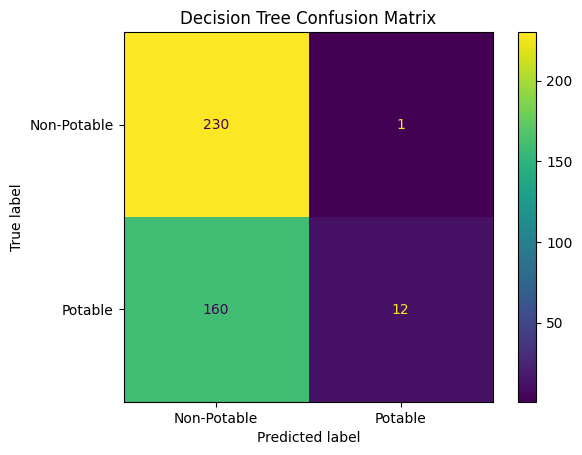

In [25]:
from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay

# decision tree
conf_mat_dt = confusion_matrix(y_true = y_test , y_pred = y_predicted_from_dt) 
ConfusionMatrixDisplay(confusion_matrix = conf_mat_dt , display_labels = ["Non-Potable" , "Potable"]).plot()
plt.title("Decision Tree Confusion Matrix") ; plt.show()

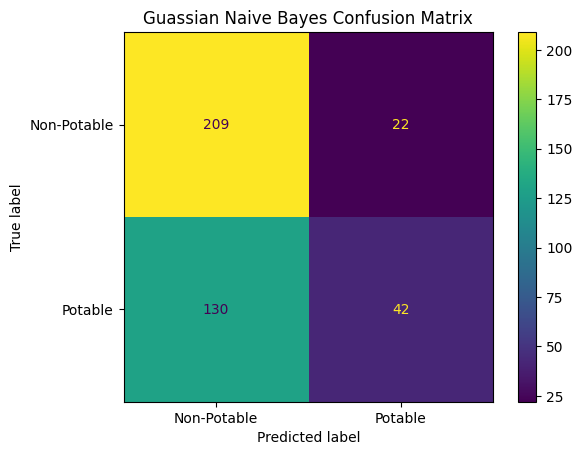

In [26]:
# guassian naive bayes
conf_mat_gnb = confusion_matrix(y_true = y_test , y_pred = y_predicted_from_gnb) 
ConfusionMatrixDisplay(confusion_matrix = conf_mat_gnb , display_labels = ["Non-Potable" , "Potable"]).plot()
plt.title("Guassian Naive Bayes Confusion Matrix") ; plt.show()

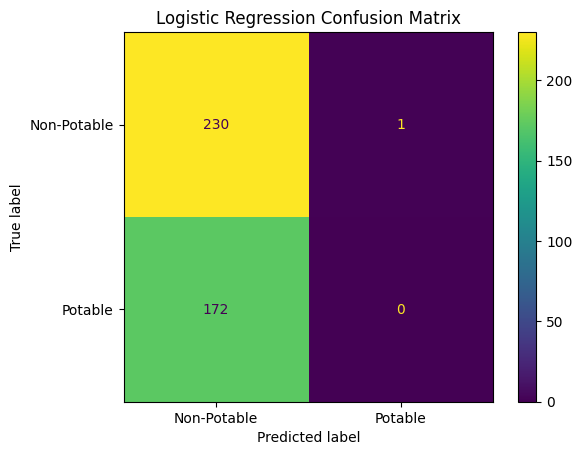

In [27]:
# logistic regression
conf_mat_log_reg = confusion_matrix(y_true = y_test , y_pred = y_predicted_from_log_reg) 
ConfusionMatrixDisplay(confusion_matrix = conf_mat_log_reg , display_labels = ["Non-Potable" , "Potable"]).plot()
plt.title("Logistic Regression Confusion Matrix") ; plt.show()

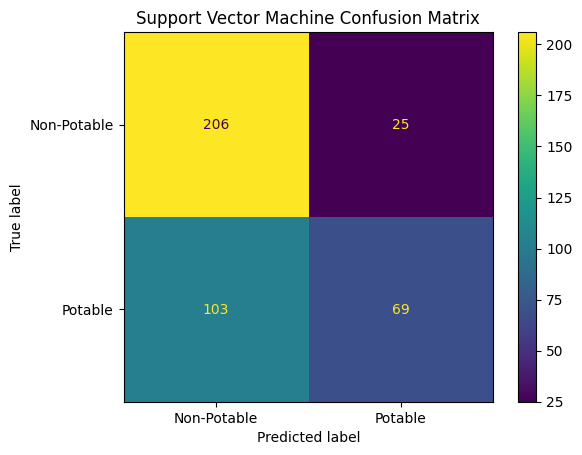

In [28]:
# support vector machine
conf_mat_svm = confusion_matrix(y_true = y_test , y_pred = y_predicted_from_svm) 
ConfusionMatrixDisplay(confusion_matrix = conf_mat_svm , display_labels = ["Non-Potable" , "Potable"]).plot()
plt.title("Support Vector Machine Confusion Matrix") ; plt.show()

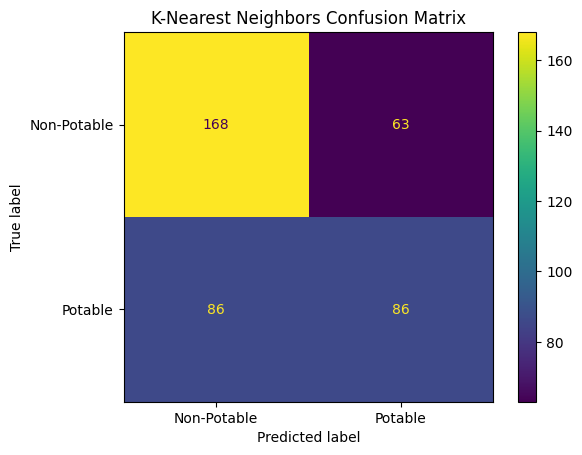

In [29]:
# k-nearest neighbours
conf_mat_knn = confusion_matrix(y_true = y_test , y_pred = y_predicted_from_knn) 
ConfusionMatrixDisplay(confusion_matrix = conf_mat_knn , display_labels = ["Non-Potable" , "Potable"]).plot()
plt.title("K-Nearest Neighbors Confusion Matrix") ; plt.show()

### Evaluation II : Accuracy

In [30]:
from sklearn.metrics import accuracy_score

In [31]:
## decision tree
accuracy_score_dt = accuracy_score(y_true = y_test , y_pred = y_predicted_from_dt)
print("Accuracy Score of Decision Tree : " , round(accuracy_score_dt , 3))

Accuracy Score of Decision Tree :  0.6


In [32]:
# guassian naive bayes
accuracy_score_gnb = accuracy_score(y_true = y_test , y_pred = y_predicted_from_gnb)
print("Accuracy Score of Guassian Naive Bayes : " , round(accuracy_score_gnb , 3))

Accuracy Score of Guassian Naive Bayes :  0.623


In [33]:
# logistic regression
accuracy_score_log_reg = accuracy_score(y_true = y_test , y_pred = y_predicted_from_log_reg)
print("Accuracy Score of Logistic Regression : " , round(accuracy_score_log_reg , 3))

Accuracy Score of Logistic Regression :  0.571


In [34]:
# support vector machine
accuracy_score_svm = accuracy_score(y_true = y_test , y_pred = y_predicted_from_svm)
print("Accuracy Score of Support Vector Machine : " , round(accuracy_score_svm , 3))

Accuracy Score of Support Vector Machine :  0.682


In [35]:
# k-nearest neighbours
accuracy_score_knn = accuracy_score(y_true = y_test , y_pred = y_predicted_from_knn)
print("Accuracy Score of K Nearest Neighbors : " , round(accuracy_score_knn , 3))

Accuracy Score of K Nearest Neighbors :  0.63


### Evaluation III : Precision

In [36]:
from sklearn.metrics import precision_score

In [37]:
## decision tree
precision_score_dt = precision_score(y_true = y_test , y_pred = y_predicted_from_dt)
print("Precision Score of Decision Tree : " , round(precision_score_dt , 3))

Precision Score of Decision Tree :  0.923


In [38]:
# guassian naive bayes
precision_score_gnb = precision_score(y_true = y_test , y_pred = y_predicted_from_gnb)
print("Precision Score of Guassian Naive Bayes : " , round(precision_score_gnb , 3))

Precision Score of Guassian Naive Bayes :  0.656


In [39]:
# logistic regression
precision_score_log_reg = precision_score(y_true = y_test , y_pred = y_predicted_from_log_reg)
print("Precision Score of Logistic Regression : " , round(precision_score_log_reg , 3))

Precision Score of Logistic Regression :  0.0


In [40]:
# support vector machine
precision_score_svm = precision_score(y_true = y_test , y_pred = y_predicted_from_svm)
print("Precision Score of Support Vector Machine : " , round(precision_score_svm , 3))

Precision Score of Support Vector Machine :  0.734


In [41]:
# k-nearest neighbours
precision_score_knn = precision_score(y_true = y_test , y_pred = y_predicted_from_knn)
print("Precision Score of Decision Tree : " , round(precision_score_knn , 3))

Precision Score of Decision Tree :  0.577


### Evaluation IV : Recall

In [42]:
from sklearn.metrics import recall_score

In [43]:
## decision tree
recall_score_dt = recall_score(y_true = y_test , y_pred = y_predicted_from_dt)
print("Recall Score of Decision Tree : " , round(recall_score_dt , 3))

Recall Score of Decision Tree :  0.07


In [44]:
# guassian naive bayes
recall_score_gnb = recall_score(y_true = y_test , y_pred = y_predicted_from_gnb)
print("Recall Score of Guassian Naive Bayes : " , round(recall_score_gnb , 3))

Recall Score of Guassian Naive Bayes :  0.244


In [45]:
# logistic regression
recall_score_log_reg = recall_score(y_true = y_test , y_pred = y_predicted_from_log_reg)
print("Recall Score of Logistic Regression : " , round(recall_score_log_reg , 3))

Recall Score of Logistic Regression :  0.0


In [46]:
# support vector machine
recall_score_svm = recall_score(y_true = y_test , y_pred = y_predicted_from_svm)
print("Recall Score of Support Vector Machine : " , round(recall_score_svm , 3))

Recall Score of Support Vector Machine :  0.401


In [47]:
# k-nearest neighbours
recall_score_knn = recall_score(y_true = y_test , y_pred = y_predicted_from_knn)
print("Recall Score of K Nearest Neighbors : " , round(recall_score_knn , 3))

Recall Score of K Nearest Neighbors :  0.5


### Evaluation V : F1-Score

In [48]:
from sklearn.metrics import f1_score

In [49]:
## decision tree
f1_score_dt = f1_score(y_true = y_test , y_pred = y_predicted_from_dt)
print("F1 Score of Decision Tree : " , round(f1_score_dt , 3))

F1 Score of Decision Tree :  0.13


In [50]:
## guassian naive bayes 
f1_score_gnb = f1_score(y_true = y_test , y_pred = y_predicted_from_gnb)
print("F1 Score of Guassian Naive Bayes : " , round(f1_score_gnb , 3))

F1 Score of Guassian Naive Bayes :  0.356


In [51]:
## logistic regression
f1_score_log_reg = f1_score(y_true = y_test , y_pred = y_predicted_from_log_reg)
print("F1 Score of Logistic Regression : " , round(f1_score_log_reg , 3))

F1 Score of Logistic Regression :  0.0


In [52]:
## support vector machine
f1_score_svm = f1_score(y_true = y_test , y_pred = y_predicted_from_dt)
print("F1 Score of Support Vector Machine : " , round(f1_score_svm , 3))

F1 Score of Support Vector Machine :  0.13


In [53]:
## k nearest neighbors
f1_score_knn = f1_score(y_true = y_test , y_pred = y_predicted_from_knn)
print("F1 Score of K Nearest Neighbors : " , round(f1_score_knn , 3))

F1 Score of K Nearest Neighbors :  0.536


### Evaluation VI : Classification Report

In [54]:
from sklearn.metrics import classification_report

In [55]:
## decision tree
report_dt = classification_report( y_true = y_test , 
                                   y_pred = y_predicted_from_dt , 
                                   target_names = ["Non-Potable" , "Potable"] ) 

print(report_dt)

              precision    recall  f1-score   support

 Non-Potable       0.59      1.00      0.74       231
     Potable       0.92      0.07      0.13       172

    accuracy                           0.60       403
   macro avg       0.76      0.53      0.44       403
weighted avg       0.73      0.60      0.48       403



In [56]:
## guassian naive bayes 
report_gnb = classification_report( y_true = y_test , 
                                   y_pred = y_predicted_from_gnb , 
                                   target_names = ["Non-Potable" , "Potable"] ) 

print(report_gnb)

              precision    recall  f1-score   support

 Non-Potable       0.62      0.90      0.73       231
     Potable       0.66      0.24      0.36       172

    accuracy                           0.62       403
   macro avg       0.64      0.57      0.54       403
weighted avg       0.63      0.62      0.57       403



In [57]:
## logistic regression
report_log_reg = classification_report( y_true = y_test , 
                                   y_pred = y_predicted_from_log_reg , 
                                   target_names = ["Non-Potable" , "Potable"] ) 

print(report_log_reg)

              precision    recall  f1-score   support

 Non-Potable       0.57      1.00      0.73       231
     Potable       0.00      0.00      0.00       172

    accuracy                           0.57       403
   macro avg       0.29      0.50      0.36       403
weighted avg       0.33      0.57      0.42       403



In [58]:
## support vector machine
report_svm = classification_report( y_true = y_test , 
                                   y_pred = y_predicted_from_svm , 
                                   target_names = ["Non-Potable" , "Potable"] ) 

print(report_svm)

              precision    recall  f1-score   support

 Non-Potable       0.67      0.89      0.76       231
     Potable       0.73      0.40      0.52       172

    accuracy                           0.68       403
   macro avg       0.70      0.65      0.64       403
weighted avg       0.70      0.68      0.66       403



In [59]:
## k nearest neighborsw
report_knn = classification_report( y_true = y_test , 
                                   y_pred = y_predicted_from_knn , 
                                   target_names = ["Non-Potable" , "Potable"] ) 

print(report_knn)

              precision    recall  f1-score   support

 Non-Potable       0.66      0.73      0.69       231
     Potable       0.58      0.50      0.54       172

    accuracy                           0.63       403
   macro avg       0.62      0.61      0.61       403
weighted avg       0.63      0.63      0.63       403



### Evaluation VII : ROC - AUC Score

In [60]:
from sklearn.metrics import roc_auc_score , roc_curve , auc

In [61]:
## For shorter command I'll define probability for class 1 from each model here

## find probabilbity predicted from each model (choosing class 1)
y_predicted_prob_from_dt_class_1 = decision_tree_model.predict_proba(x_test_scaled)[:,1] # decision tree
y_predicted_prob_from_gnb_class_1 = guassian_naive_bayes_model.predict_proba(x_test_scaled)[:,1] # guassian naive bayes
y_predicted_prob_from_log_reg_class_1 = logistic_regression_model.predict_proba(x_test_scaled)[:,1] # logistic regression

## in svm , use decision function instead (svm doesnt have predict_proba)
y_predicted_prob_from_svm = support_vector_machine_model.decision_function(x_test_scaled) # support vector machine
y_predicted_prob_from_knn_class_1 = k_nearest_neighbors_model.predict_proba(x_test_scaled)[:,1] # k nearest neighbors

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


AUC Score on Decision Tree :  0.5


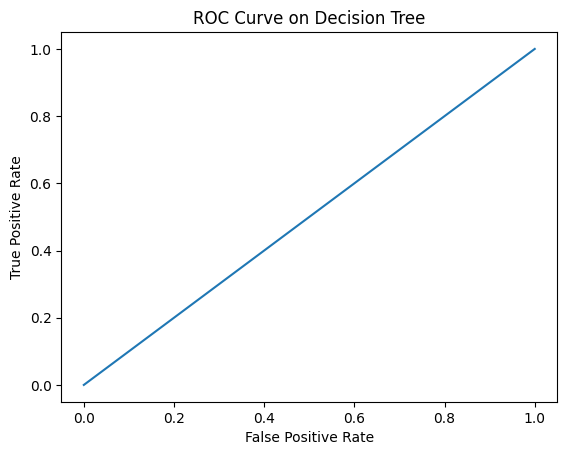

In [62]:
## decision tree
fpr_dt , tpr_dt , _ = roc_curve(y_true = y_test , y_score = y_predicted_prob_from_dt_class_1) # another one is threshold (which we didnt use)
auc_score_dt = auc(fpr_dt , tpr_dt)
print("AUC Score on Decision Tree : " , round(auc_score_dt,3))

plt.plot(fpr_dt , tpr_dt) 
plt.title("ROC Curve on Decision Tree") ; plt.xlabel("False Positive Rate")  ; plt.ylabel("True Positive Rate")
plt.show()


AUC Score on Guassian Naive Bayes :  0.468


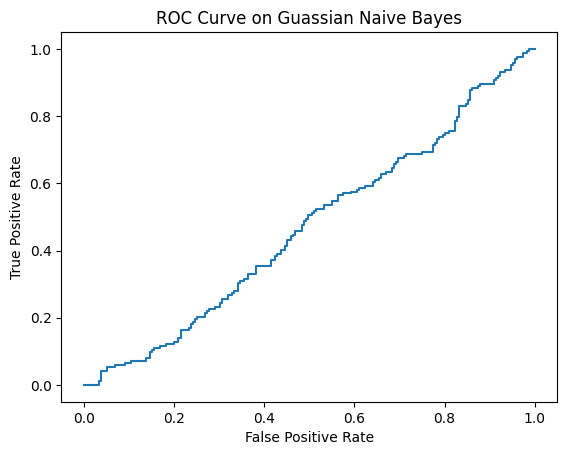

In [63]:
## guassian naive bayes
## decision tree
fpr_gnb , tpr_gnb , _ = roc_curve(y_true = y_test , y_score = y_predicted_prob_from_gnb_class_1) # another one is threshold (which we didnt use)
auc_score_gnb = auc(fpr_gnb , tpr_gnb)
print("AUC Score on Guassian Naive Bayes : " , round(auc_score_gnb,3))

plt.plot(fpr_gnb , tpr_gnb) 
plt.title("ROC Curve on Guassian Naive Bayes") ; plt.xlabel("False Positive Rate")  ; plt.ylabel("True Positive Rate")
plt.show()

AUC Score on Logistic Regression :  0.465


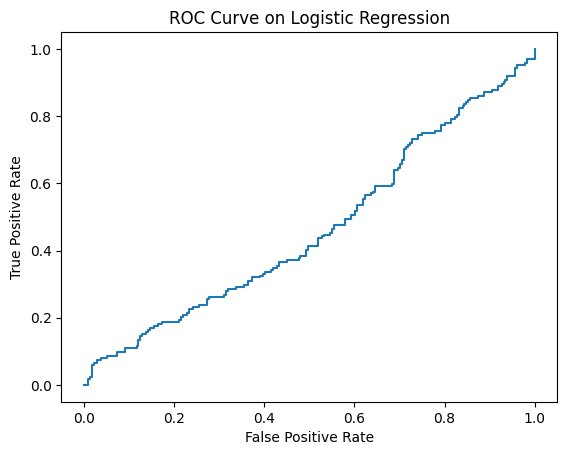

In [64]:
## logistic regression
fpr_log_reg , tpr_log_reg , _ = roc_curve(y_true = y_test , y_score = y_predicted_prob_from_log_reg_class_1) # another one is threshold (which we didnt use)
auc_score_log_reg = auc(fpr_log_reg , tpr_log_reg)
print("AUC Score on Logistic Regression : " , round(auc_score_log_reg,3))

plt.plot(fpr_log_reg , tpr_log_reg) 
plt.title("ROC Curve on Logistic Regression") ; plt.xlabel("False Positive Rate")  ; plt.ylabel("True Positive Rate")
plt.show()

AUC Score on Support Vector Machine :  0.726


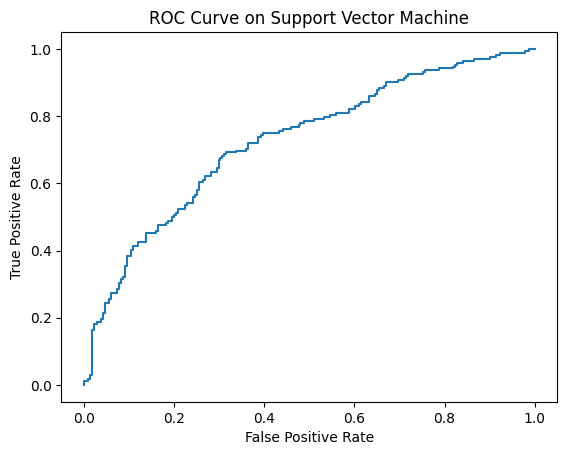

In [65]:
## support vector machine
fpr_svm , tpr_svm , _ = roc_curve(y_true = y_test , y_score = y_predicted_prob_from_svm) # another one is threshold (which we didnt use)
auc_score_svm = auc(fpr_svm , tpr_svm)
print("AUC Score on Support Vector Machine : " , round(auc_score_svm,3))

plt.plot(fpr_svm , tpr_svm) 
plt.title("ROC Curve on Support Vector Machine") ; plt.xlabel("False Positive Rate")  ; plt.ylabel("True Positive Rate")
plt.show()

AUC Score on K Nearest Neighbors :  0.649


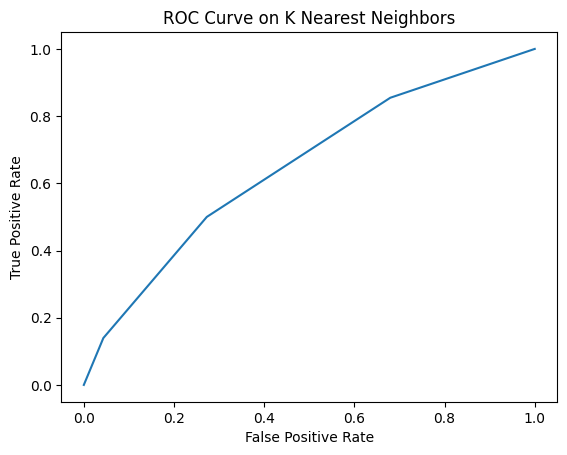

In [66]:
## k nearest neighbors
fpr_knn , tpr_knn , _ = roc_curve(y_true = y_test , y_score = y_predicted_prob_from_knn_class_1) # another one is threshold (which we didnt use)
auc_score_knn = auc(fpr_knn , tpr_knn)
print("AUC Score on K Nearest Neighbors : " , round(auc_score_knn,3))

plt.plot(fpr_knn , tpr_knn) 
plt.title("ROC Curve on K Nearest Neighbors") ; plt.xlabel("False Positive Rate")  ; plt.ylabel("True Positive Rate")
plt.show()

## Part III : Summarize Data & Conclusion

In [67]:
result_df = pd.DataFrame({ 
                         "Model Name" : ["Decision Tree" , "Guassian Naive Bayes" , "Logistic Regression" , "Support Vector Machine" , "K Nearest Neighbors"] ,
                         "Accuracy" : [accuracy_score_dt , accuracy_score_gnb , accuracy_score_log_reg , accuracy_score_svm , accuracy_score_knn] ,
                         "Precision" : [precision_score_dt , precision_score_gnb , precision_score_log_reg , precision_score_svm , precision_score_knn] ,
                         "Recall" : [recall_score_dt , recall_score_gnb , recall_score_log_reg , recall_score_svm , recall_score_knn] ,
                         "F1-Score" : [f1_score_dt , f1_score_gnb , f1_score_log_reg , f1_score_svm , f1_score_knn]  ,
                         "AUC Score" : [auc_score_dt , auc_score_gnb , auc_score_log_reg , auc_score_svm , auc_score_knn]
                         })

# Applies a smooth background gradient to visualize patterns easily (AI-Assisted)
result_df.style.background_gradient(cmap="Purples", subset=["Accuracy", "Precision", "Recall", "F1-Score", "AUC Score"]).hide(axis='index')

Model Name,Accuracy,Precision,Recall,F1-Score,AUC Score
Decision Tree,0.600496,0.923077,0.069767,0.129730,0.500000
Guassian Naive Bayes,0.622829,0.656250,0.244186,0.355932,0.468137
Logistic Regression,0.570720,0.000000,0.000000,0.000000,0.464890
Support Vector Machine,0.682382,0.734043,0.401163,0.129730,0.725511
K Nearest Neighbors,0.630273,0.577181,0.500000,0.535826,0.649074


### Conclusion from result
(will write later)

# Optimizing Data & Model Part

## Part IV : (To-be Optimized) Data Preprocessing 
In this part , I choose `Data Imputation` Techniques (which means filling NULL values with some rules)

but but but , we have to do `Data Imputation` to prevent `Data Leakage`

#### Data Preprocessing To-do 
- Step 1 : Read Data & Get `Feature & Target`

- Step 2 : Do `train_test_split` before imputation

- Step 3 : Impute data on `x_train_imputed` and `x_test_imputed`

- Step 4 : Clean some outliers & Do `Feature Scaling`

In [68]:
## read data again (old data was Nan-cleaned already)
import pandas as pd
new_data = pd.read_csv("./water_potability.csv")

In [69]:
## get feature & targe first 
feature_x_imputed = new_data[ ['ph','Hardness','Solids','Chloramines','Sulfate','Conductivity','Organic_carbon','Trihalomethanes','Turbidity'] ] # DataFrame
target_y_imputed = new_data['Potability'] # Series

In [70]:
## train test split with uncleaned train & test data
from sklearn.model_selection import train_test_split
x_train_imputed , x_test_imputed , y_train_imputed , y_test_imputed = train_test_split(feature_x_imputed , target_y_imputed , random_state = 42)

In [71]:
## see which column we should do data imputation
print(feature_x.isnull().sum())
## we can see that ph , Sulfate , Trihalomethanes should do 

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
dtype: int64


In [72]:
## "Mean Value" Imputation (manual) --< another solution is using Imputor (but i wanna manual impute btw lol)

## ph column
mean_ph = new_data['ph'].mean() ## find mean value of that column 
x_train_imputed["ph"] = x_train_imputed["ph"].fillna(mean_ph) ## fill na with mean (x_train)
x_test_imputed["ph"] = x_test_imputed["ph"].fillna(mean_ph) ## fill na with mean (x_test)

## sulfate column 
mean_sulfate = new_data['Sulfate'].mean()
x_train_imputed["Sulfate"] = x_train_imputed["Sulfate"].fillna(mean_sulfate) ## fill na with mean (x_train)
x_test_imputed["Sulfate"] = x_test_imputed["Sulfate"].fillna(mean_sulfate) ## fill na with mean (x_test)

## Trihalomethanes column 
mean_trihalomethanes = new_data['Trihalomethanes'].mean()
x_train_imputed["Trihalomethanes"] = x_train_imputed["Trihalomethanes"].fillna(mean_trihalomethanes) ## fill na with mean (x_train)
x_test_imputed["Trihalomethanes"] = x_test_imputed["Trihalomethanes"].fillna(mean_trihalomethanes) ## fill na with mean (x_test)

In [73]:
## check missing values after impute data 
print(x_train_imputed.isnull().sum()) ## cleaned
print(x_test_imputed.isnull().sum()) ## cleaned

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
dtype: int64
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
dtype: int64


In [74]:
## Cleaning outliers (Percentile 95 of Data)

## get value at p95 first 
p95_ph , p95_sulfate , p95_trihalomethanes = x_train_imputed[['ph','Sulfate','Trihalomethanes']].quantile(0.95)

## clip data (ceil data that shouldn't more than p95 of original data) --> do with train & test data
x_train_imputed[['ph','Sulfate','Trihalomethanes']] = x_train_imputed[['ph','Sulfate','Trihalomethanes']].clip(upper = [p95_ph , p95_sulfate , p95_trihalomethanes] , axis = 1)
x_test_imputed[['ph','Sulfate','Trihalomethanes']] = x_test_imputed[['ph','Sulfate','Trihalomethanes']].clip(upper = [p95_ph , p95_sulfate , p95_trihalomethanes] , axis = 1)

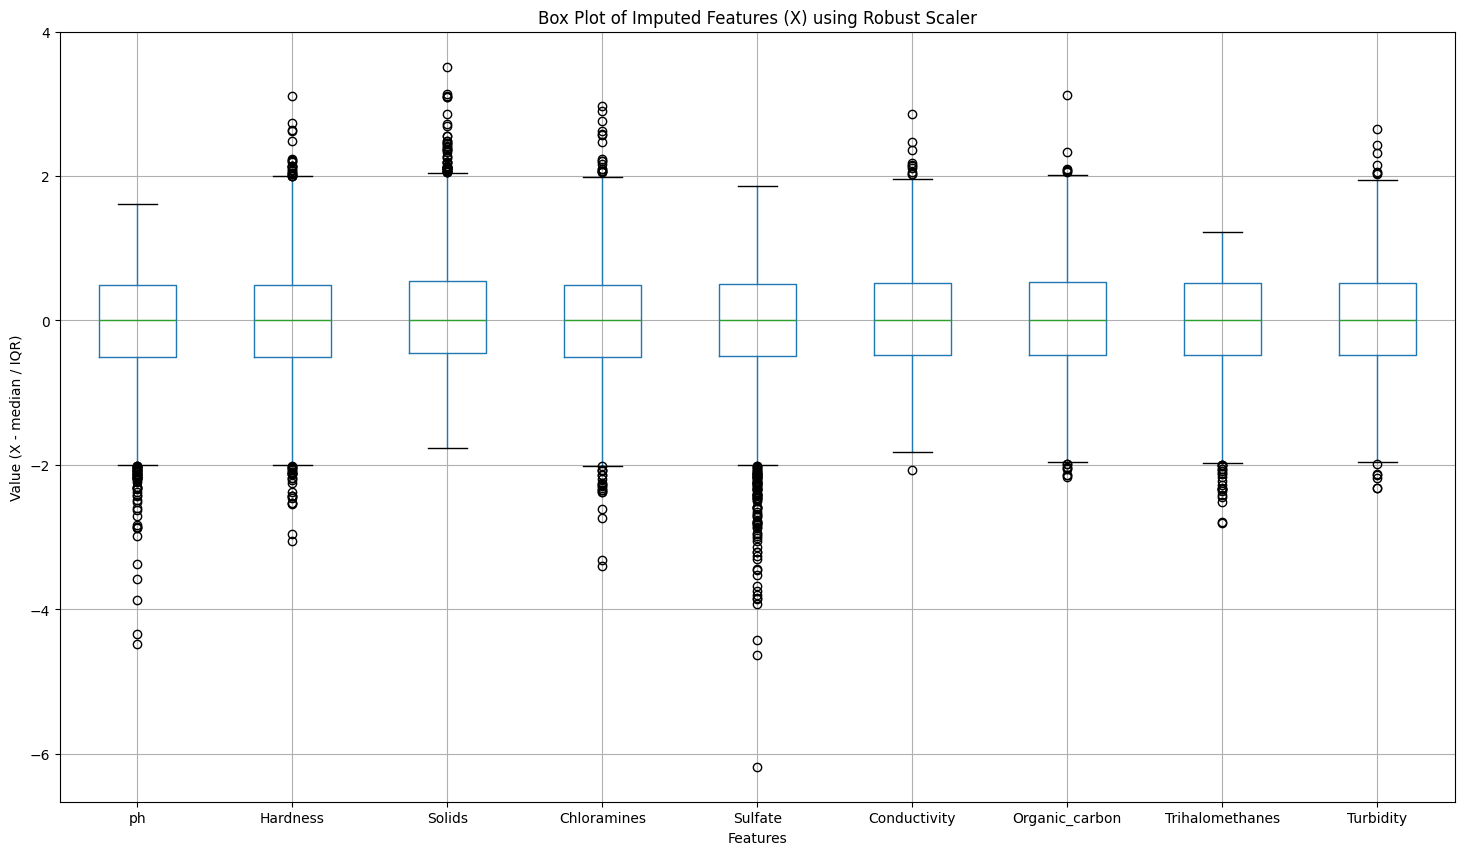

In [75]:
## Feature Scaling 
from sklearn.preprocessing import MinMaxScaler , RobustScaler , StandardScaler ## read from docs 

## Imma try using 1 of these scaler for easier ways (using StandardScaler)
scaler = RobustScaler() ## choosing robust scaler because it uses "median" to calculate , which is better look in boxplot

## fit & transform data
x_train_imputed_scaled = scaler.fit_transform(x_train_imputed) # return np array 
x_test_imputed_scaled = scaler.transform(x_test_imputed) ## Don't fit because fit will learn from this data

## Y (target) shouldn't be scaled bcz Y is between (0,1) which should be use in this form

## convert scaled data to DataFrame first 
x_train_imputed_scaled_df = pd.DataFrame(data = x_train_imputed_scaled , columns = feature_x.columns)

## plotting box plot for trend
x_train_imputed_scaled_df.boxplot(figsize = (18,10))

## Decorate Box Plot
plt.title("Box Plot of Imputed Features (X) using Robust Scaler")
plt.xlabel("Features") ; plt.ylabel("Value (X - median / IQR)") ;
plt.show() 

## Part V : Processing Improved Data

### Data Processing To-do 


#### Part I : Optimizing Model
- Step 1 : Decision Tree --> Optimize Parameter `max_depth`

- Step 2 : Logistic Regression --> Optimize `C-value`

- Step 3 : Support Vector Machine --> Optimize `C-value` & `Kernel`

- Step 4 : K-Nearest Neighbors --> Optimize `k-value`

### Part II : Optimizing with `GridSearchCV`

In [76]:
## เลือก scoring = "f1" แทน "accuracy" เพราะ data imbalance (Potability 0:1 ~ 60:40)
## ที่เจอมาก่อนหน้านี้คือโมเดลที่ accuracy สูง (เช่น Logistic Regression) บางตัว จริงๆ แล้ว recall ของ class Potable = 0 (ทายคลาส 0 ตลอด)
## accuracy ไม่ลงโทษพฤติกรรมนี้ แต่ f1 จะลงโทษ เพราะงั้นใช้ f1 เป็นตัวเลือก hyperparameter จะได้โมเดลที่ "แยกคลาส" ได้จริง ไม่ใช่แค่เดาคลาสส่วนใหญ่เก่ง

from sklearn.model_selection import GridSearchCV

## Step 1 : Decision Tree --> Optimize `max_depth`
from sklearn.tree import DecisionTreeClassifier

param_grid_dt = {"max_depth": range(1, 11)}

grid_search_dt = GridSearchCV(
    DecisionTreeClassifier(random_state = 42) ,
    param_grid_dt ,
    cv = 5 ,
    scoring = "f1" ,
)
grid_search_dt.fit(x_train_imputed , y_train_imputed) # Decision Tree ไม่ต้อง scale data

print("Best max_depth :" , grid_search_dt.best_params_["max_depth"])
print("Best CV F1-Score :" , grid_search_dt.best_score_)

Best max_depth : 9
Best CV F1-Score : 0.3871150259056194


In [77]:
## Step 2 : Logistic Regression --> Optimize `C-value`
from sklearn.linear_model import LogisticRegression

param_grid_log_reg = {"C": [0.01, 0.1, 1, 10, 100]}

grid_search_log_reg = GridSearchCV(
    LogisticRegression(max_iter = 1000 , random_state = 42) ,
    param_grid_log_reg ,
    cv = 5 ,
    scoring = "f1" ,
)
grid_search_log_reg.fit(x_train_imputed_scaled , y_train_imputed)

print("Best C :" , grid_search_log_reg.best_params_["C"])
print("Best CV F1-Score :" , grid_search_log_reg.best_score_)

Best C : 1
Best CV F1-Score : 0.0041025641025641026


In [79]:
## Step 4 : K-Nearest Neighbors --> Optimize `k-value`
from sklearn.neighbors import KNeighborsClassifier

param_grid_knn = {"n_neighbors": range(1, 21)}

grid_search_knn = GridSearchCV(
    KNeighborsClassifier() ,
    param_grid_knn ,
    cv = 5 ,
    scoring = "f1" ,
)
grid_search_knn.fit(x_train_imputed_scaled , y_train_imputed)

print("Best n_neighbors :" , grid_search_knn.best_params_["n_neighbors"])
print("Best CV F1-Score :" , grid_search_knn.best_score_)

## Note : n_neighbors ที่ CV เลือกอาจออกมาเป็นค่าต่ำมาก (เช่น 1) ซึ่งเป็นสัญญาณ overfitting
## (จำเฉพาะเพื่อนบ้านที่ใกล้สุดตัวเดียว ไวต่อ noise มาก) เหมือนที่เจอปัญหา max_depth สูงไปตอน Decision Tree ก่อนหน้านี้
## ถ้าเป็นแบบนั้นควรพิจารณาเลือกค่าที่สูงขึ้นมาหน่อยแทน best_params_ ตรงๆ เพื่อความเสถียร

Best n_neighbors : 1
Best CV F1-Score : 0.49149244719690754


In [80]:
## สรุปผล GridSearchCV เทียบทั้ง 4 โมเดล (ด้วย f1-score จาก Cross-Validation)
optimize_summary_df = pd.DataFrame({
    "Model Name": ["Decision Tree", "Logistic Regression", "Support Vector Machine", "K-Nearest Neighbors"],
    "Best Params": [grid_search_dt.best_params_, grid_search_log_reg.best_params_, grid_search_svm.best_params_, grid_search_knn.best_params_],
    "Best CV F1-Score": [grid_search_dt.best_score_, grid_search_log_reg.best_score_, grid_search_svm.best_score_, grid_search_knn.best_score_],
})

optimize_summary_df.style.background_gradient(cmap = "Purples", subset = ["Best CV F1-Score"]).hide(axis = 'index')

AttributeError: 'GridSearchCV' object has no attribute 'best_params_'